In [50]:
%pip install numpy pandas matplotlib scikit-learn

You should consider upgrading via the '/Users/aniketwagh/Code/Machine learning/01-pass-fail/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [51]:
import numpy as np
import pandas as pd

In [52]:
df = pd.read_csv("placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,1


# Data pre processing

In [53]:
# remove unnecessary first column which is just an index
df = df.iloc[:,1:]

In [54]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,1


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       150 non-null    float64
 1   iq         150 non-null    float64
 2   placement  150 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.6 KB


# EDA

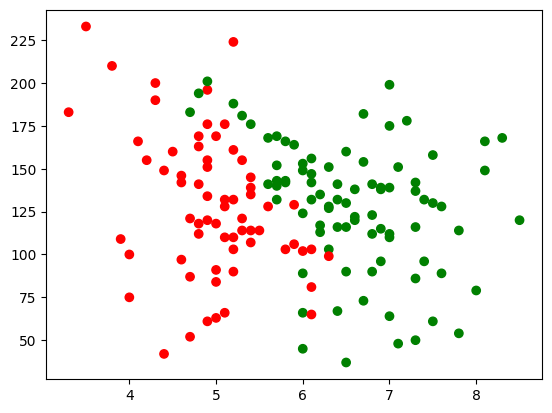

In [56]:
from matplotlib import pyplot as plt

plt.scatter(df['cgpa'], df['iq'], color = df['placement'].map({0:'red', 1:'green'}))

## Extract input output calls

In [57]:
X = df.iloc[:, :2]
Y = df.iloc[:, -1]

X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
145,4.2,155.0
146,6.5,116.0
147,5.6,168.0
148,5.1,110.0


## Train test Split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

## Scaling

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test

array([[-1.47899277,  1.80876485],
       [ 0.96251911,  0.21581853],
       [ 0.96251911, -0.86327413],
       [-0.91556696,  1.19214047],
       [-0.91556696, -1.76251802],
       [-0.25823683, -0.04110829],
       [ 0.7747105 ,  1.34629656],
       [-1.19727987,  0.31858926],
       [-0.16433253,  0.57551609],
       [ 1.43204062, -0.86327413],
       [ 2.08937075,  0.93521364],
       [-0.25823683,  0.29289658],
       [ 1.99546644, -1.30004974],
       [-0.63385405,  0.06166244],
       [ 1.05642341,  0.24151122],
       [ 0.6808062 , -0.19526439],
       [-0.16433253,  1.01229169],
       [-0.44604544,  1.19214047],
       [-0.72775835, -1.63405461],
       [-1.10337556, -1.09450828],
       [ 1.05642341, -0.50357658],
       [-1.10337556, -0.22095707],
       [-0.72775835, -0.04110829],
       [-1.10337556, -1.99375216],
       [ 1.15032771, -2.09652289],
       [-0.63385405, -1.01743023],
       [-1.57289708,  0.65259414],
       [ 1.80765784, -0.40080585],
       [ 0.11738038,

## Train model

In [60]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

clf.fit(X_train, Y_train)

LogisticRegression()

## Model Evaluation

In [61]:
y_pred = clf.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, y_pred)

0.9666666666666667

## Store Model

In [63]:
import pickle

pickle.dump(clf, open('model.pkl', 'wb'))

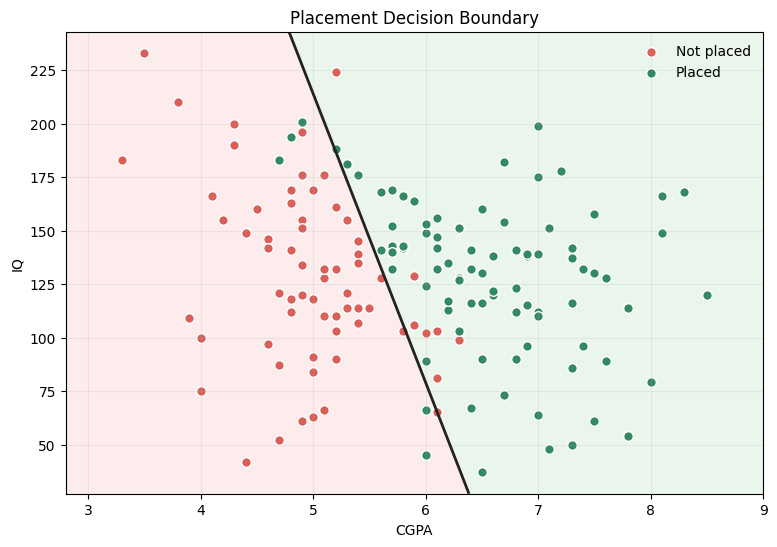

In [64]:
cgpa_values = np.linspace(X["cgpa"].min() - 0.5, X["cgpa"].max() + 0.5, 300)
iq_values = np.linspace(X["iq"].min() - 10, X["iq"].max() + 10, 300)
cgpa_grid, iq_grid = np.meshgrid(cgpa_values, iq_values)

raw_coefficients = clf.coef_[0] / scaler.scale_
raw_intercept = clf.intercept_[0] - np.sum(clf.coef_[0] * scaler.mean_ / scaler.scale_)
decision_scores = (
    raw_coefficients[0] * cgpa_grid
    + raw_coefficients[1] * iq_grid
    + raw_intercept
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(
    cgpa_grid,
    iq_grid,
    decision_scores,
    levels=[decision_scores.min() - 1, 0, decision_scores.max() + 1],
    colors=["#FCE8E6", "#E5F3E8"],
    alpha=0.8,
)
ax.contour(cgpa_grid, iq_grid, decision_scores, levels=[0], colors="#222222", linewidths=2)
ax.scatter(
    X.loc[Y == 0, "cgpa"],
    X.loc[Y == 0, "iq"],
    color="#D95F59",
    edgecolors="white",
    s=48,
    label="Not placed",
)
ax.scatter(
    X.loc[Y == 1, "cgpa"],
    X.loc[Y == 1, "iq"],
    color="#338A62",
    edgecolors="white",
    s=48,
    label="Placed",
)
ax.set(
    xlabel="CGPA",
    ylabel="IQ",
    title="Placement Decision Boundary",
)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()